# Reference notebook — Guardrailed Agent

Per [ADR-006](../consulting/guardrailed-agent/decisions/006-personal-interaction-surfaces.md) step 4. 
Three example questions across three personas (Dispatcher, TechnicianLead, Owner — see [ADR-008](../consulting/guardrailed-agent/decisions/008-dataset-pivot-hvac-home-services.md)) 
running on top of the shared `gagent_client` library.

**Three demonstrations:**

1. **PII redaction** — same prompt, two personas, *different responses* (Lake Formation is the gate).
2. **Governance probe** — predict per-persona column visibility *without running the query* (the differentiator from any other SQL-over-MCP server).
3. **ML inference read** — Owner queries `equipment_telemetry_daily.predicted_failure_30d` and we chart the at-risk equipment.

The notebook is environment-driven; persona role ARNs come from environment variables (set by SMUS or the operator).

In [1]:
%matplotlib inline
import os
import sys
import time
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import numpy as np

# When running outside SMUS, make sure gagent_client + mcp_server are importable.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from gagent_client import (
    FlagPersonaResolver, Persona,
    invoke as agent_invoke, assume_persona,
)
from mcp_server.governance import (
    fetch_persona_tag_grants, fetch_table_metadata,
    fetch_column_lf_tags, compute_column_visibility,
)

# Configuration from env. SMUS sets these via the project's role + secrets.
PERSONA_ARNS = {
    'dispatcher': os.environ['GAGENT_DISPATCHER_ROLE_ARN'],
    'technician_lead': os.environ['GAGENT_TECHNICIAN_LEAD_ROLE_ARN'],
    'owner': os.environ['GAGENT_OWNER_ROLE_ARN'],
}
AGENT_ID = os.environ['GAGENT_AGENT_ID']
AGENT_ALIAS_ID = os.environ['GAGENT_AGENT_ALIAS_ID']
GLUE_DATABASE = os.environ['GAGENT_GLUE_DATABASE']
ATHENA_WORKGROUP = os.environ['GAGENT_ATHENA_WORKGROUP']
REGION = os.environ.get('AWS_REGION', 'us-east-1')

resolver = FlagPersonaResolver(PERSONA_ARNS)
print(f'Region: {REGION}')
print(f'Agent: {AGENT_ID} (alias {AGENT_ALIAS_ID})')
print(f'Database: {GLUE_DATABASE}')
print(f'Personas: {resolver.known_roles()}')

Matplotlib is building the font cache; this may take a moment.


Region: us-east-1
Agent: HRS5SMWB9S (alias DWBVSXSEBZ)
Database: guardrailed_agent_demo
Personas: ['dispatcher', 'owner', 'technician_lead']


## Example 1 — PII redaction across personas

Same question, two personas. Lake Formation enforces column visibility; the agent never sees the columns it isn't allowed to.

*Dispatcher* has `pii=[false] AND sensitivity=[other]`. *Owner* has both tags fully open.

In [2]:
QUESTION = 'Show me the contact information for one customer in tempe-mesa.'

responses = {}
for role in ('dispatcher', 'owner'):
    persona = resolver.resolve(role)
    response = agent_invoke(
        QUESTION, persona,
        agent_id=AGENT_ID, agent_alias_id=AGENT_ALIAS_ID, region=REGION,
        enable_trace=True,
    )
    responses[role] = response
    print(f'=== {role} (duration={response.duration_seconds:.1f}s) ===')
    print(response.text)
    print()

=== dispatcher (duration=7.9s) ===
I'm sorry, but access to customer contact information in the **Tempe-Mesa** region has been denied for your current user role. This is likely due to data governance permissions restricting access to customer PII (personally identifiable information) for your persona.

Please contact your system administrator if you believe you should have access to this data.



=== owner (duration=11.4s) ===
No customer records tagged to a **tempe-mesa** service region were found in the system. The closest result returned was from the **west-valley** region:

| Field | Value |
|---|---|
| **Customer ID** | 392456de-3eb1-3b90-4668-5257bdd640fb |
| **Name** | Danielle Johnson |
| **Email** | danielle.johnson768@example.com |
| **Phone** | 433-218-1960 |
| **Address** | 33890 Jennifer Squares, Goodyear, 85314 |
| **Customer Type** | Residential |
| **Service Tier** | Standard |
| **Service Region** | West Valley |

You may want to verify the exact region name used in your system for the Tempe/Mesa area (e.g., "east-valley" or similar).



## Example 2 — Governance probe (predict column visibility)

The MCP server's `explain_governance` tool runs this same probe — no query executes. We use the underlying helpers from `mcp_server.governance` directly here.

For each (persona × table), we count how many columns Lake Formation would let the persona see. The chart shows the dual-tag scheme (pii + sensitivity) at work: Dispatcher loses PII; TechnicianLead keeps PII but loses sensitivity=high; Owner sees everything.

In [3]:
glue = boto3.client('glue', region_name=REGION)
lf = boto3.client('lakeformation', region_name=REGION)

TABLES = ['customer', 'service_job', 'parts_inventory', 'technician_utilization_daily']

table_columns = {}
table_tags = {}
for table in TABLES:
    cols, _, _ = fetch_table_metadata(glue, GLUE_DATABASE, table)
    table_columns[table] = cols
    table_tags[table] = fetch_column_lf_tags(lf, GLUE_DATABASE, table, cols)

visibility = {role: {} for role in PERSONA_ARNS}
for role, arn in PERSONA_ARNS.items():
    grants = fetch_persona_tag_grants(lf, arn)
    for table in TABLES:
        cols = table_columns[table]
        tags = table_tags[table]
        visible = sum(
            1 for c in cols
            if compute_column_visibility(c, tags.get(c, {}), grants).visible
        )
        visibility[role][table] = (visible, len(cols))

for table in TABLES:
    cells_per_row = ' | '.join(
        f'{role}: {visibility[role][table][0]}/{visibility[role][table][1]}'
        for role in ('dispatcher', 'technician_lead', 'owner')
    )
    print(f'{table:<32}  {cells_per_row}')

customer                          dispatcher: 7/15 | technician_lead: 15/15 | owner: 15/15
service_job                       dispatcher: 11/12 | technician_lead: 12/12 | owner: 12/12
parts_inventory                   dispatcher: 9/11 | technician_lead: 9/11 | owner: 11/11
technician_utilization_daily      dispatcher: 7/8 | technician_lead: 7/8 | owner: 8/8


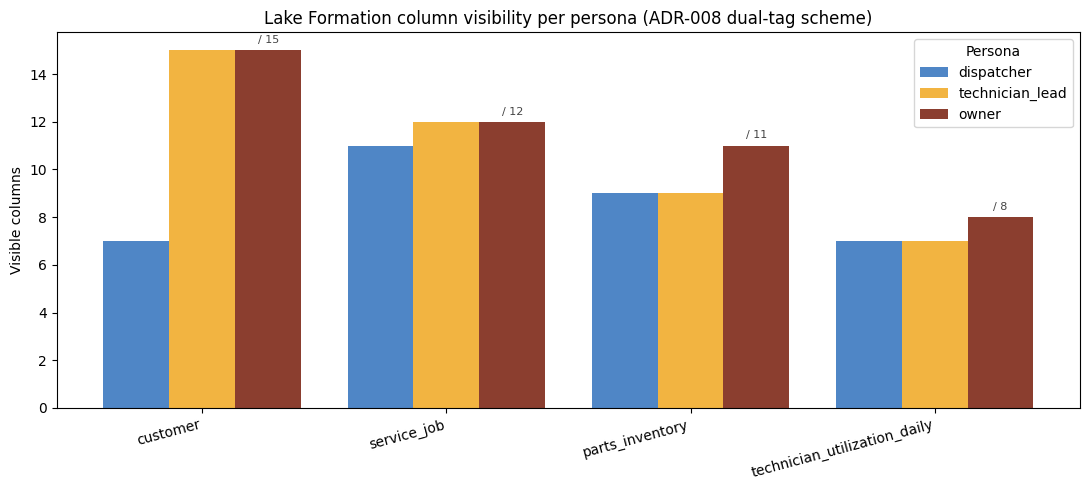

In [4]:
x = np.arange(len(TABLES))
width = 0.27
personas_ordered = ['dispatcher', 'technician_lead', 'owner']
colors = {'dispatcher': '#4F86C6', 'technician_lead': '#F2B441', 'owner': '#8B3E2F'}

fig, ax = plt.subplots(figsize=(11, 5))
for i, role in enumerate(personas_ordered):
    visible_counts = [visibility[role][t][0] for t in TABLES]
    total_counts = [visibility[role][t][1] for t in TABLES]
    ax.bar(x + (i - 1) * width, visible_counts, width, label=role, color=colors[role])

ax.set_xticks(x)
ax.set_xticklabels(TABLES, rotation=15, ha='right')
ax.set_ylabel('Visible columns')
ax.set_title('Lake Formation column visibility per persona (ADR-008 dual-tag scheme)')
ax.legend(title='Persona', loc='upper right')

# Annotate Owner's bars with total column count for context.
for j, t in enumerate(TABLES):
    total = visibility['owner'][t][1]
    ax.text(x[j] + width, visibility['owner'][t][0] + 0.3, f'/ {total}', fontsize=8, ha='center', color='#444')

plt.tight_layout()
plt.show()

## Example 3 — ML inference read on `equipment_telemetry_daily.predicted_failure_30d`

The Owner runs an Athena query under their assumed-role credentials and we chart the top-20 equipment most likely to fail in the next 30 days. The score is synthetic — see [ADR-008 open items](../consulting/guardrailed-agent/decisions/008-dataset-pivot-hvac-home-services.md). The reading pattern is the production-shape one: governed access, audited query, model-friendly results.

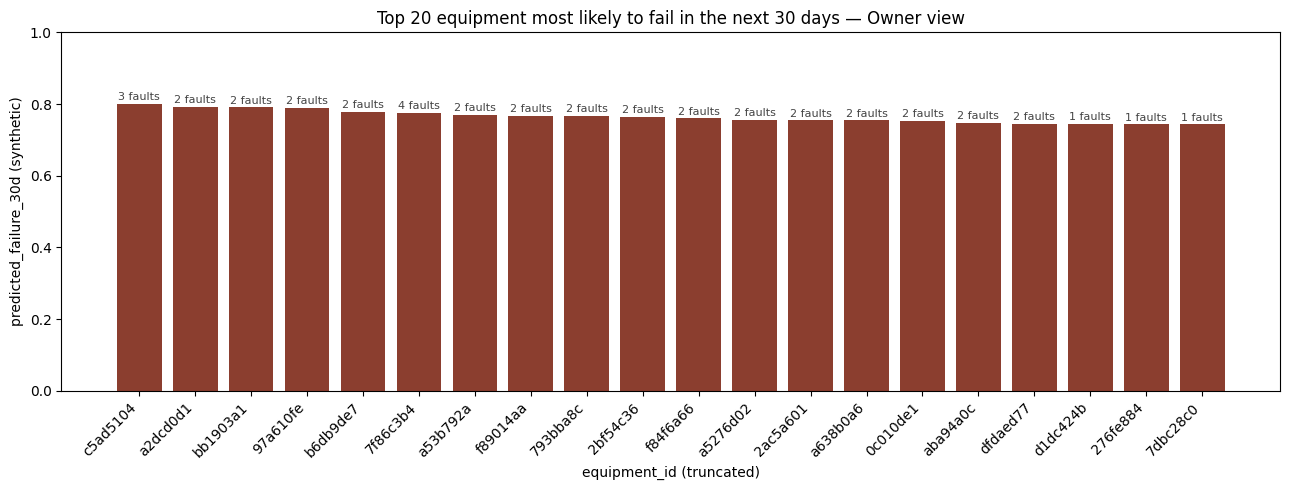

In [5]:
owner = resolver.resolve('owner')
creds = assume_persona(owner)
athena = boto3.client(
    'athena', region_name=REGION,
    aws_access_key_id=creds['AccessKeyId'],
    aws_secret_access_key=creds['SecretAccessKey'],
    aws_session_token=creds['SessionToken'],
)

QUERY = '''
SELECT equipment_id, predicted_failure_30d, fault_code_count, efficiency_index
FROM equipment_telemetry_daily
WHERE telemetry_date = (SELECT MAX(telemetry_date) FROM equipment_telemetry_daily)
ORDER BY predicted_failure_30d DESC
LIMIT 20
'''

exec_id = athena.start_query_execution(
    QueryString=QUERY,
    WorkGroup=ATHENA_WORKGROUP,
    QueryExecutionContext={'Database': GLUE_DATABASE},
)['QueryExecutionId']

while True:
    state = athena.get_query_execution(QueryExecutionId=exec_id)['QueryExecution']['Status']['State']
    if state == 'SUCCEEDED':
        break
    if state in ('FAILED', 'CANCELLED'):
        raise RuntimeError(f'Athena query {state}')
    time.sleep(1)

rows = []
cols = None
first = True
for page in athena.get_paginator('get_query_results').paginate(QueryExecutionId=exec_id):
    rs = page['ResultSet']
    if first:
        cols = [c['Name'] for c in rs['ResultSetMetadata']['ColumnInfo']]
        data = rs['Rows'][1:]
        first = False
    else:
        data = rs['Rows']
    for r in data:
        rows.append(dict(zip(cols, [c.get('VarCharValue') for c in r['Data']])))

ids = [r['equipment_id'][:8] for r in rows]
scores = [float(r['predicted_failure_30d']) for r in rows]
fault_counts = [int(r['fault_code_count']) for r in rows]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(ids, scores, color='#8B3E2F')
ax.set_ylim(0, 1)
ax.set_ylabel('predicted_failure_30d (synthetic)')
ax.set_xlabel('equipment_id (truncated)')
ax.set_title('Top 20 equipment most likely to fail in the next 30 days — Owner view')
plt.xticks(rotation=45, ha='right')

# Annotate fault_code_count above each bar to show the supporting signal.
for bar, fc in zip(bars, fault_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{fc} faults', ha='center', fontsize=8, color='#444')

plt.tight_layout()
plt.show()

## What just happened

1. **Same agent, same prompt, two personas, two responses.** Lake Formation hid PII columns from the Dispatcher; the model literally never saw them. No agent-side or Lambda-side filtering.
2. **Visibility predicted *before* any query ran.** The probe walks Glue + Lake Formation and tells us *exactly* which columns each persona will see. Same path as the MCP server's `explain_governance` tool.
3. **A real ML-read pattern.** Owner authenticates via STS, runs Athena under their persona role, gets the top-20 at-risk equipment. Every step is in CloudTrail. The agent could chain this query and answer 'which units should I dispatch a tech to?' under exactly the same governance.

Next: the same `gagent_client` library is the foundation of the MCP server (Claude Code IDE) and the `gra` CLI (terminal / scriptable). Three surfaces, one library.